# 1. Import Libraries

In [68]:
import os, sys, glob, yaml, math
from pathlib import Path
from collections import Counter, defaultdict
from IPython.display import display
from PIL import Image

import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from ultralytics import YOLO

print("Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

Version: 2.11.0+cu128
CUDA Available: True
Device Name: NVIDIA GeForce RTX 4050 Laptop GPU


# 2. Dataset Preparation / Define Dataset Location

In [2]:
dataset=r"D:\python1\Week-11-Deep-Learning-Project\bdd100k"
print("Dataset Path : " , dataset)

# Project working directory

PROJECT_PATH = Path(r"D:\python1\Week-11-Deep-Learning-Project\bdd100k_hazard_project")
PROJECT_PATH.mkdir(parents=True, exist_ok=True)

# BDD100K classes

classes = [
    "pedestrian", "rider", "car", "truck", "bus",
    "train", "motorcycle", "bicycle", "traffic light", "traffic sign"
]

print(f"Dataset Path: {dataset}")
print(f"Project Path: {PROJECT_PATH.resolve()}")

Dataset Path :  D:\python1\Week-11-Deep-Learning-Project\bdd100k
Dataset Path: D:\python1\Week-11-Deep-Learning-Project\bdd100k
Project Path: D:\python1\Week-11-Deep-Learning-Project\bdd100k_hazard_project


# 3. Exploratory Data Analysis

In [3]:
dataset = Path(r"D:\python1\Week-11-Deep-Learning-Project\bdd100k")
label_files = list(dataset.glob("**/*.txt"))
print("Number of label files found:", len(label_files))

Number of label files found: 100000


In [4]:
count = Counter()

for file in label_files[:3000]:
    f = open(file, "r")

    for line in f:
        class_id = int(line.split()[0])
        count[class_id] += 1

    f.close()

print(count)


Counter({2: 30164, 8: 10687, 7: 8304, 0: 4399, 4: 1288, 3: 517, 5: 300, 1: 197, 6: 168, 9: 6})


In [5]:
box_area=[]

for file in label_files[:3000]:
    with open(file, "r") as f:
        
        for line in f:
            data=line.split()

            # data[0] = Class ID
            # data[1] = X center
            # data[2] = Y center
            # data[3] = Width
            # data[4] = Height

            width=float(data[3])
            height=float(data[4])

            area=width*height
            box_area.append(area)

print("Number of bounding boxes: ", len(box_area))

Number of bounding boxes:  56030


In [6]:
table=pd.DataFrame({
    "Class ID": list(count.keys()),
    "Number of Objects": list(count.values())
})
print(table)

   Class ID  Number of Objects
0         8              10687
1         7               8304
2         2              30164
3         1                197
4         6                168
5         0               4399
6         3                517
7         4               1288
8         5                300
9         9                  6


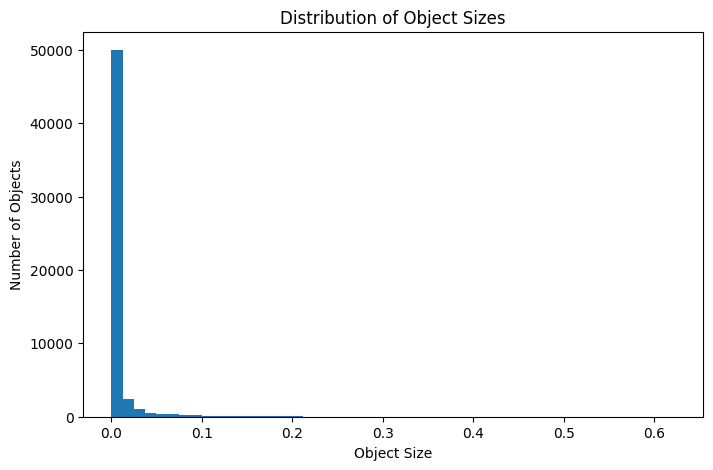

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(box_area, bins=50)

plt.xlabel("Object Size")
plt.ylabel("Number of Objects")
plt.title("Distribution of Object Sizes")

plt.show()

# 4. YOLO Dataset Conversion

In [8]:
for file in label_files[:5000]:
    with open(file, "r") as f:
        lines = f.readlines()

    good_lines = []

    for line in lines:
        data = line.split()

        if len(data) == 5:
            w = float(data[3])
            h = float(data[4])

            if w > 0 and h > 0:
                good_lines.append(line)

    with open(file, "w") as f:
        f.writelines(good_lines)

In [9]:
# Check YOLO label files

total = 0
wrong_boxes = 0
wrong_lines = 0

for file in label_files[:5000]:
    with open(file) as f:
        for line in f:
            data = line.split()

            # Each line should have 5 values
            if len(data) != 5:
                wrong_lines += 1
                continue

            x = float(data[1])
            y = float(data[2])
            width = float(data[3])
            height = float(data[4])

            total += 1

            # Check if box values are valid
            if not (0 <= x <= 1 and 0 <= y <= 1 and
                    0 < width <= 1 and 0 < height <= 1):
                wrong_boxes += 1

print("Total boxes:", total)
print("Wrong boxes:", wrong_boxes)
print("Wrong lines:", wrong_lines)

Total boxes: 93568
Wrong boxes: 0
Wrong lines: 0


# 5. Train / Validation Split / Update existing data.yaml Path

In [10]:
# Update data.yaml

yaml_file = Path(r"D:\python1\Week-11-Deep-Learning-Project\bdd100k\data.yaml")

data = {
    "path": str(yaml_file.parent),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 10,
    "names": [
        "person", "rider", "car", "bus", "truck",
        "bike", "motor", "traffic light", "traffic sign", "train"
    ]
}

with open(yaml_file, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml updated successfully!")

data.yaml updated successfully!


# 6. Train YOLO Model

yolo11s.pt → YOLO model, 

data.yaml → Dataset information,

epochs=15 → Train 15 times,

imgsz=640 → Image size,

batch=8 → 8 images at once,

device=0 → Use GPU,

optimizer="AdamW" → Training method,

lr0=0.001 → Learning speed,

patience=5 → Stop if there is no improvement for 5 epochs.

In [11]:
model = YOLO("yolo11s.pt")

training_args = dict(
    data=str(yaml_file),
    epochs=15,
    imgsz=640,
    batch=8,          
    workers=2,         
    device=0 if torch.cuda.is_available() else "cpu",
    optimizer="AdamW",
    lr0=0.001,
    patience=5,
    save=True,
    amp=True,          # Enables FP16 Mixed Precision (halves VRAM usage)
    project=str(dataset / "runs"),
    name="hazard_detector"
)

results = model.train(**training_args)
print("Training execution block compiled.")

New https://pypi.org/project/ultralytics/8.4.155 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.152  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\python1\Week-11-Deep-Learning-Project\bdd100k\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=

# 7. Model Evaluation

In [13]:
# Load the trained model
model = YOLO(str(dataset / "runs/hazard_detector/weights/best.pt"))

# Test the model
results = model.val(data=str(yaml_file))

# Show the score
print("mAP@50:", results.box.map50)
print("mAP@50-95:", results.box.map)

Ultralytics 8.4.152  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 261.283.1 MB/s, size: 40.0 KB)
val: Scanning D:\python1\Week-11-Deep-Learning-Project\bdd100k\val\labels.cache... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 4.8it/s 2:090.2ss
                   all      10000     185554      0.702      0.444      0.485       0.27
                person       3220      13264      0.727      0.486      0.567      0.277
                 rider        515        649      0.606      0.365      0.388      0.189
                   car       9879     102524      0.751      0.713      0.759      0.464
                   bus       1242       1597       0.67      0.495       

# 8. Confusion Matrix

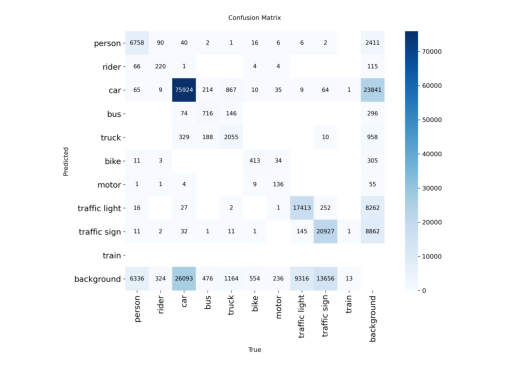

In [14]:
img = cv2.imread(r"D:\python1\Week-11-Deep-Learning-Project\bdd100k\runs\hazard_detector\confusion_matrix.png")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 9. Precision, Recall & F1

In [19]:
model = YOLO(r"D:\python1\Week-11-Deep-Learning-Project\bdd100k\runs\hazard_detector\weights\best.pt")

metrics = model.val()

p=metrics.box.p
r=metrics.box.r

f1 = 2 * p * r / (p + r + 1e-6)

print("Precision:", p)
print("Recall:", r)
print("F1 Score:", f1)

Ultralytics 8.4.152  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.40.1 ms, read: 15.14.8 MB/s, size: 63.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning D:\python1\Week-11-Deep-Learning-Project\bdd100k\val\labels.cache... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 1.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 4.7it/s 2:120.2ss
                   all      10000     185554      0.702      0.444      0.485       0.27
                person       3220      13264      0.727      0.486      0.567      0.277
                 rider        515        649      0.606      0.365      0.388      0.189
           

# 10. Diagnostic Error Analysis

In [20]:
errors= [
    "Night: Headlight Glare",
    "Rain: Reflections",
    "Sun: Low Contrast",
    "Small objects: Hard to detect",
    "Occlusion: Objects blocked",
    "Border objects: Partially visible"
]

for error in errors:
    print(" ", errors)

  ['Night: Headlight Glare', 'Rain: Reflections', 'Sun: Low Contrast', 'Small objects: Hard to detect', 'Occlusion: Objects blocked', 'Border objects: Partially visible']
  ['Night: Headlight Glare', 'Rain: Reflections', 'Sun: Low Contrast', 'Small objects: Hard to detect', 'Occlusion: Objects blocked', 'Border objects: Partially visible']
  ['Night: Headlight Glare', 'Rain: Reflections', 'Sun: Low Contrast', 'Small objects: Hard to detect', 'Occlusion: Objects blocked', 'Border objects: Partially visible']
  ['Night: Headlight Glare', 'Rain: Reflections', 'Sun: Low Contrast', 'Small objects: Hard to detect', 'Occlusion: Objects blocked', 'Border objects: Partially visible']
  ['Night: Headlight Glare', 'Rain: Reflections', 'Sun: Low Contrast', 'Small objects: Hard to detect', 'Occlusion: Objects blocked', 'Border objects: Partially visible']
  ['Night: Headlight Glare', 'Rain: Reflections', 'Sun: Low Contrast', 'Small objects: Hard to detect', 'Occlusion: Objects blocked', 'Border obj

# 11. Object Detection

In [122]:
video_path = r"D:\python1\Week-11-Deep-Learning-Project\videos\bdd100k\videos\train\00ce6f6d-50bbee62.mov"

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = model.predict(frame, conf=0.35, verbose=False)[0]

    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        width = x2 - x1
        height = y2 - y1
        area = width * height

        # Risk logic
        if area > 50000:
            risk = "HIGH"
            color = (0, 0, 255)       # Red
        elif area > 15000:
            risk = "MEDIUM"
            color = (0, 165, 255)     # Orange
        else:
            risk = "LOW"
            color = (0, 255, 0)       # Green

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
        cv2.putText(frame, risk, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow("Risk Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

# 12. Bounding Box Analysis

In [123]:
video_path = r"D:\python1\Week-11-Deep-Learning-Project\videos\bdd100k\videos\train\00ce6f6d-50bbee62.mov"

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = model.predict(frame, conf=0.35, verbose=False)[0]

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        # Your risk logic
        if conf >= 0.70:
            risk = "HIGH RISK"
            color = (0, 0, 255)

        elif conf >= 0.40:
            risk = "MEDIUM RISK"
            color = (0, 165, 255)

        else:
            risk = "LOW RISK"
            color = (0, 255, 0)

        # Bounding box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)

        # Label
        cv2.putText(frame, risk, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow("Risk Detection Video", frame)

    # Press Q to stop
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

# 13. Lane Detection & Ego-Lane Geometry

In [125]:
video_path = r"D:\python1\Week-11-Deep-Learning-Project\videos\bdd100k\videos\train\00ce6f6d-50bbee62.mov"

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Lane points
    left_bottom = (200, 700)
    right_bottom = (1080, 700)

    left_top = (500, 400)
    right_top = (780, 400)

    # Draw lane lines
    cv2.line(frame, left_bottom, left_top, (255,255,0), 3)
    cv2.line(frame, right_bottom, right_top, (255,255,0), 3)

    # Measure road width
    road_width = math.dist(left_bottom, right_bottom)

    cv2.putText(frame, f"Road Width: {road_width:.0f} px",
                (400, 650),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)

    cv2.imshow("Road Measurement", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

# 14. Relative Distance Estimation

In [128]:
import cv2

video_path = r"D:\python1\Week-11-Deep-Learning-Project\videos\bdd100k\videos\train\00ce6f6d-50bbee62.mov"

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = model.predict(frame, conf=0.35, verbose=False)[0]

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        height = y2 - y1

        # Distance logic
        if height > 300:
            distance = "DANGER"
            color = (0, 0, 255)       # Red

        elif height > 150:
            distance = "CAUTION"
            color = (0, 165, 255)     # Orange

        else:
            distance = "SAFE"
            color = (0, 255, 0)       # Green

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        cv2.putText(frame, distance, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow("Distance Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

# 15. Multi-Object Tracking (ByteTrack)

In [131]:
video_path = r"D:\python1\Week-11-Deep-Learning-Project\videos\bdd100k\videos\train\00c4c672-26d36ad8.mov"

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        verbose=False
    )[0]

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        cls = int(box.cls[0])
        name = result.names[cls]

        height = y2 - y1

        if height > 300:
            risk = "DANGER"
            color = (0, 0, 255)
        elif height > 150:
            risk = "CAUTION"
            color = (0, 165, 255)
        else:
            risk = "SAFE"
            color = (0, 255, 0)

        # Tracking ID
        if box.id is not None:
            track_id = int(box.id[0])
        else:
            track_id = 0

        # Draw box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)

        # Object + ID + Risk
        label = f"{name} ID:{track_id} {risk}"

        cv2.putText(frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    cv2.imshow("Vehicle and Person Risk Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

# 16. Motion & Approach Velocity Estimation

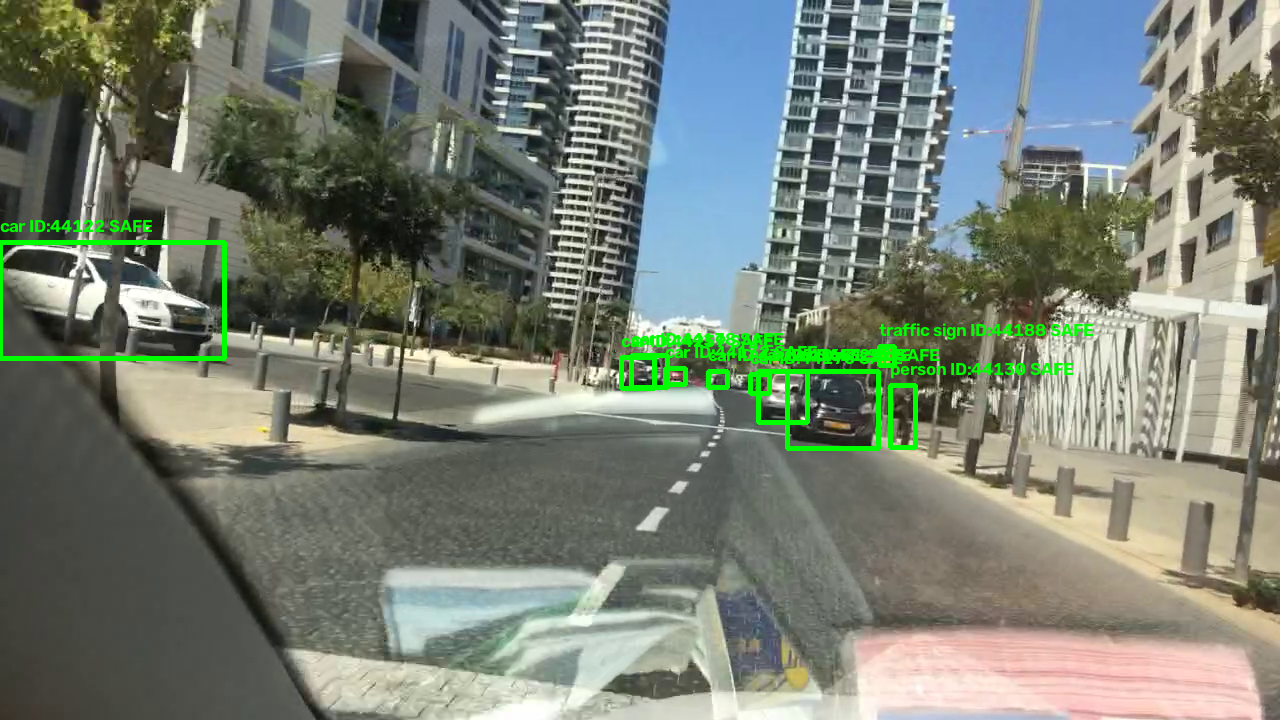

In [132]:
video_path = r"D:\python1\Week-11-Deep-Learning-Project\videos\bdd100k\videos\train\00cb28b9-08a22af7.mov"

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        verbose=False
    )[0]

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Object name
        cls = int(box.cls[0])
        name = result.names[cls]

        # Tracking ID
        track_id = int(box.id[0]) if box.id is not None else 0

        # Distance logic
        height = y2 - y1

        if height > 300:
            risk = "DANGER"
            color = (0, 0, 255)       # Red
        elif height > 150:
            risk = "CAUTION"
            color = (0, 165, 255)     # Orange
        else:
            risk = "SAFE"
            color = (0, 255, 0)       # Green

        # Box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)

        # Label
        label = f"{name} ID:{track_id} {risk}"

        cv2.putText(frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    clear_output(wait=True)
    display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

    time.sleep(0.03)

cap.release()

# 17. Hazard Detection

In [133]:
def is_in_lane(x , y):

    if x > 200 and x >1080:
        print("Hazard")

    else:
        print("No Hazard")

is_in_lane(500 , 700)

No Hazard


# 18. Collision Risk

In [134]:
# Cell 18: Collision Risk

def collision_risk(distance, in_lane):

    if distance < 10 and in_lane:
        return "HIGH RISK"

    elif distance < 20 and in_lane:
        return "MEDIUM RISK"

    else:
        return "LOW RISK"


print("Test 1:", collision_risk(8, True))
print("Test 2:", collision_risk(30, False))

Test 1: HIGH RISK
Test 2: LOW RISK


# 19. Low / Medium / High Classification

In [115]:
def classify_risk(score):

    if score >= 70:
        return "HIGH RISK"

    elif score >= 40:
        return "MEDIUM RISK"

    else:
        return "LOW RISK"


print("Score 80:", classify_risk(80))
print("Score 50:", classify_risk(50))
print("Score 10:", classify_risk(10))

Score 80: HIGH RISK
Score 50: MEDIUM RISK
Score 10: LOW RISK


# 20. Video Demonstration & Folder Batch Processing

In [135]:
video_path = r"D:\python1\Week-11-Deep-Learning-Project\videos\bdd100k\videos\train\00ce6f6d-50bbee62.mov"

cap = cv2.VideoCapture(video_path)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    result = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        verbose=False
    )[0]

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Object name
        cls = int(box.cls[0])
        name = result.names[cls]

        # Tracking ID
        track_id = int(box.id[0]) if box.id is not None else 0

        # Distance
        height = y2 - y1

        if height > 300:
            risk = "DANGER"
            color = (0, 0, 255)       # Red

        elif height > 150:
            risk = "CAUTION"
            color = (0, 165, 255)     # Orange

        else:
            risk = "SAFE"
            color = (0, 255, 0)       # Green

        # Bounding box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)

        # Label
        cv2.putText(
            frame,
            f"{name} ID:{track_id} {risk}",
            (x1, y1 - 10),
            0,
            0.6,
            color,
            2
        )

    # Title
    cv2.putText(
        frame,
        "ROAD SAFETY",
        (50, 50),
        0,
        1,
        (255, 255, 255),
        2
    )

    cv2.imshow("Video", frame)

    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()